### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [ ]:
pip install polars

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

In [ ]:
pip install scipy

In [19]:
import polars as pl
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import numpy as np


In [12]:
df= pl.read_csv(r"C:\Users\Ready2Use\Desktop\my-folder\Ironhack-week5\Day2\lab-eda-bivariate\amz_uk_price_prediction_dataset.csv", try_parse_dates=True)
print(df)

shape: (2_443_651, 9)
┌─────────┬────────────┬─────────────┬───────┬───┬───────┬─────────────┬─────────────┬─────────────┐
│ uid     ┆ asin       ┆ title       ┆ stars ┆ … ┆ price ┆ isBestSelle ┆ boughtInLas ┆ category    │
│ ---     ┆ ---        ┆ ---         ┆ ---   ┆   ┆ ---   ┆ r           ┆ tMonth      ┆ ---         │
│ i64     ┆ str        ┆ str         ┆ f64   ┆   ┆ f64   ┆ ---         ┆ ---         ┆ str         │
│         ┆            ┆             ┆       ┆   ┆       ┆ bool        ┆ i64         ┆             │
╞═════════╪════════════╪═════════════╪═══════╪═══╪═══════╪═════════════╪═════════════╪═════════════╡
│ 1       ┆ B09B96TG33 ┆ Echo Dot    ┆ 4.7   ┆ … ┆ 21.99 ┆ false       ┆ 0           ┆ Hi-Fi       │
│         ┆            ┆ (5th        ┆       ┆   ┆       ┆             ┆             ┆ Speakers    │
│         ┆            ┆ generation, ┆       ┆   ┆       ┆             ┆             ┆             │
│         ┆            ┆ 2022…       ┆       ┆   ┆       ┆           

In [ ]:
#1. **Crosstab Analysis**:
# Create a crosstab between the product `category` and the `isBestSeller` status.
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])

# Display the crosstab
print(crosstab_result)

col_0                           False  True 
row_0                                       
3D Printers                       247      1
3D Printing & Scanning           4065      2
Abrasive & Finishing Products     245      5
Action Cameras                   1696      1
Adapters                          251      3
...                               ...    ...
Wind Instruments                  243      7
Window Treatments                 234      5
Women                           17559    213
Women's Sports & Outdoor Shoes   1939     20
eBook Readers & Accessories       246      0

[296 rows x 2 columns]


In [14]:
#    Are there categories where being a best-seller is more prevalent? 
# *Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*
if True not in crosstab_result.columns:
    crosstab_result[True] = 0
if False not in crosstab_result.columns:
    crosstab_result[False] = 0

# Calculate the proportion of bestsellers for each category
crosstab_result['Proportion_Bestsellers'] = (crosstab_result[True] 
                                             / (crosstab_result[True] + crosstab_result[False]))

# Sort the categories based on the proportion of bestsellers
sorted_categories = crosstab_result.sort_values(by='Proportion_Bestsellers', ascending=False)

# Show the sorted DataFrame
print(sorted_categories)

col_0                           False  True  Proportion_Bestsellers
row_0                                                              
Grocery                          9008   556                0.058135
Smart Home Security & Lighting     98     6                0.057692
Health & Personal Care           9017   552                0.057686
Mobile Phone Accessories          248    11                0.042471
Power & Hand Tools               8353   306                0.035339
...                               ...   ...                     ...
Bedding Collections              6309     0                0.000000
CPUs                              249     0                0.000000
CD, Disc & Tape Players          8798     0                0.000000
Blank Media Cases & Wallets       243     0                0.000000
eBook Readers & Accessories       246     0                0.000000

[296 rows x 3 columns]


In [22]:
top_5_categories = sorted_categories.head(5)
display(top_5_categories)

col_0,False,True,Proportion_Bestsellers
row_0,,,
Grocery,9008,556,0.058135
Smart Home Security & Lighting,98,6,0.057692
Health & Personal Care,9017,552,0.057686
Mobile Phone Accessories,248,11,0.042471
Power & Hand Tools,8353,306,0.035339


The top 5 categories with the most bestsellers are:
1. Grocery
2. Smart Home Security & Lighting
3. Health & Personal care
4. Mobile Phone Accessories
5. Power & Hand Tools

In [15]:
#2. **Statistical Tests**:
    # Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    

# Perform the Chi-Square test
chi2, p, dof, ex = chi2_contingency(crosstab_result)

# Output the results
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 36684.23786636857
p-value: 0.0
Degrees of freedom: 590


In [20]:
# Calculate Cramér's V
n = crosstab_result.values.sum()  # Total number of observations in crosstab_result
min_dim = min(crosstab_result.shape) - 1  # Minimum dimension minus one

cramers_v = np.sqrt(chi2 / (n * min_dim))

# Output computed Cramér's V
print("Cramér's V:", cramers_v)

Cramér's V: 0.08663731815334759


There is a relationship between category and bestseller status as show by Chi2 and p-value. But Cramer V shows that the relationship is weak.

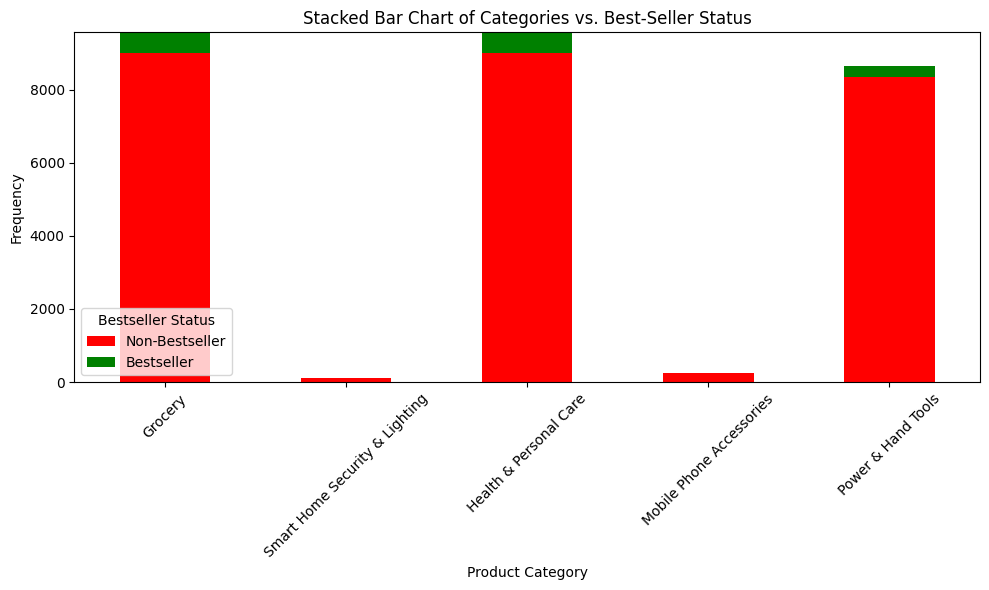

In [23]:
#3. **Visualizations**:
# Visualize the relationship between product categories and the best-seller status using a stacked bar chart.
# Plot a stacked bar chart
ax = top_5_categories.plot(kind='bar', stacked=True, color=['red', 'green'], figsize=(10, 6))

# Set titles and labels
plt.title('Stacked Bar Chart of Categories vs. Best-Seller Status')
plt.xlabel('Product Category')
plt.ylabel('Frequency')
plt.legend(title='Bestseller Status', labels=['Non-Bestseller', 'Bestseller'])
plt.xticks(rotation=45)  # Rotate x-axis labels for readability

# Display the plot
plt.tight_layout()  # Adjust layout for better fitting
plt.show()